# [LAB 11] 5. ARIMA 모델링
## 연습문제
![alt text](image-38.png)

In [1]:
# 라이브러리 기본 참조
from hossam import load_data
from helpers import *

📦 아이티윌 이광호 강사가 제작한 라이브러리를 사용중입니다.
📚 자세한 사용 방법은 https://py.hossam.kr 을 참고하세요.
📧 Email: leekh4232@gmail.com
🎬 Youtube: https://www.youtube.com/@hossam-codingclub
📝 Blog: https://blog.hossam.kr/
🔖 Version: 0.5.31


In [2]:
origin = load_data('temperatures_seoul')
df = my_ts.set_index(origin, '날짜', freq='MS')
print(f'데이터셋 크기: {df.shape[0]}행 | 인덱스 가격: {df.index.freqstr}')
df.head()

📚 1973년 1월부터 2023년 8월까지 서울의 월평균 기온 데이터 (출처: 기상청)
데이터셋 크기: 602행 | 인덱스 가격: MS


,평균기온(℃)
날짜,
1973-07-01,26.816
1973-08-01,25.884
1973-09-01,20.323
1973-10-01,13.039
1973-11-01,4.723


In [5]:
d=0       
D=1        
s=12       
p=1        
q=3        
P=3        
Q=2        

print(f'p 상한={p}, 차분 d={d}, q 상한={q}')
print(f'P 상한={P}, 계절차분 D={D}, Q 상한={Q}, 계절주기 s={s}')
print(f'모형 차수: ARIMA({p}, {d}, {q}) x ({P}, {D}, {Q})_{s}')

p 상한=1, 차분 d=0, q 상한=3
P 상한=3, 계절차분 D=1, Q 상한=2, 계절주기 s=12
모형 차수: ARIMA(1, 0, 3) x (3, 1, 2)_12


In [6]:
source = my_ts.set_index(origin, '날짜', freq='MS')

best_fit = my_ts.fit_model(source, '평균기온(℃)', p=p, d=0, q=q, P=P, D=1, Q=Q, s=12, log=False)

시도한 조합 96가지 | 적합 성공 96가지
AIC 최적: (1,0,1)(2,1,1,12)  |  BIC 최적: (1,0,1)(0,1,1,12)


,모형,p,d,q,P,D,Q,s,계수 수,AIC,BIC
순위,,,,,,,,,,,
1,"(1,0,1)(2,1,1,12)",1,0,1,2,1,1,12,6,2057.303,2083.584
2,"(1,0,3)(0,1,1,12)",1,0,3,0,1,1,12,6,2058.069,2084.350
3,"(1,0,3)(1,1,2,12)",1,0,3,1,1,2,12,8,2058.478,2093.519
4,"(1,0,1)(3,1,2,12)",1,0,1,3,1,2,12,8,2058.858,2093.899
5,"(1,0,1)(2,1,2,12)",1,0,1,2,1,2,12,7,2059.191,2089.851
6,"(1,0,1)(3,1,1,12)",1,0,1,3,1,1,12,7,2059.234,2089.895
7,"(1,0,2)(2,1,1,12)",1,0,2,2,1,1,12,7,2059.278,2089.939
8,"(1,0,1)(0,1,1,12)",1,0,1,0,1,1,12,4,2060.042,2077.562
9,"(1,0,1)(1,1,2,12)",1,0,1,1,1,2,12,6,2060.341,2086.622


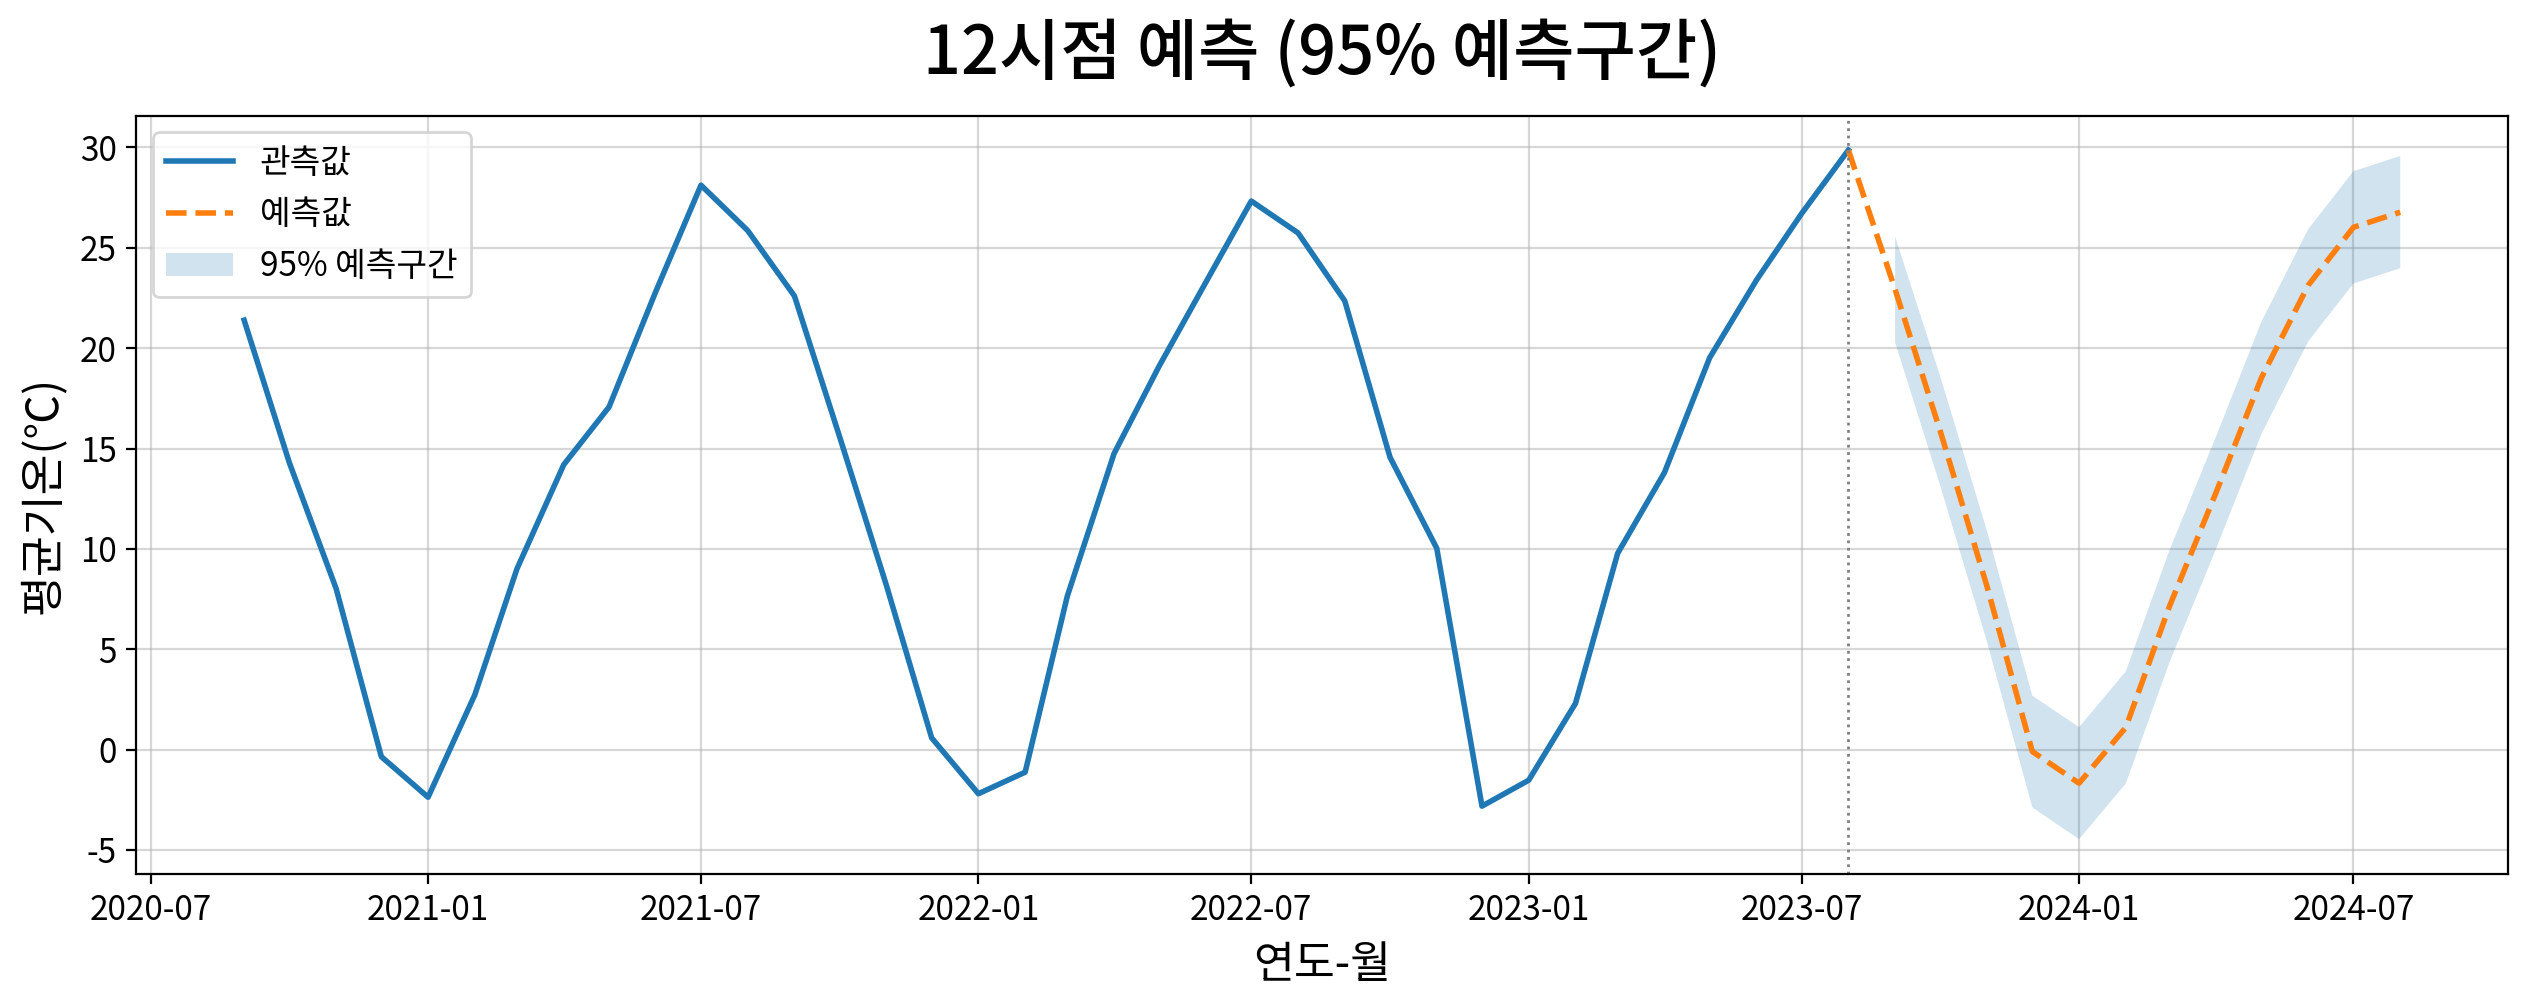

,pred,lower,upper
시점,,,
2023-09-01,22.927,20.290,25.563
2023-10-01,15.855,13.129,18.581
2023-11-01,8.119,5.354,10.884
2023-12-01,-0.094,-2.877,2.689
2024-01-01,-1.672,-4.463,1.119
2024-02-01,1.103,-1.691,3.898
2024-03-01,7.146,4.350,9.942
2024-04-01,12.828,10.031,15.625
2024-05-01,18.530,15.733,21.327


In [7]:
my_ts.predict(best_fit, steps=s, history=36, xlabel='연도-월', ylabel='평균기온(℃)')

- 문제 1. 96가지
- 문제 2. 4개
- 문제 3. (1,0,1)(2,1,1,12)
- 문제 4. 26.775도
- 문제 5. 95% 예측구간은 23.978~29.573이다.